---
title: "Exercise 1: Statistical Fine-Mapping"
format:
  html:
    embed-resources: true
    toc: true
    toc-depth: 3
---

# Overview

This notebook is a guided introduction to statistical fine-mapping in a post-GWAS workflow. You will inspect a GWAS summary-statistics table, apply basic quality-control filters, and produce the standard plots used to assess signal quality before moving to gene-level interpretation.

::: {.callout-note}
## Learning goals
By the end of this notebook, you should be able to:
- inspect the main columns in a GWAS summary-statistics file and describe their role in downstream analysis
- apply basic quality-control filters, including INFO and minor-allele-frequency thresholds, and explain why they matter
- interpret Manhattan, QQ, and p-value distribution plots to judge signal strength and possible inflation
- connect SNP-level association results to the fine-mapping, gene-mapping, and pathway steps that follow
:::

## Setup and helper functions

In [4]:
out_dir <- "output/fm_out/"
dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)

library(susieR)
library(data.table)
library(ggplot2)
source("scripts/finemapping/helpers.R")

data_dir <- "input/finemapping/"

---

## Overview

Fine-mapping narrows a GWAS signal from hundreds of candidate SNPs in linkage
disequilibrium (LD) to a small **credible set** (the set of variants that
collectively contain the causal variant with 95% probability). If you increase the probability to 99% for example, then more SNPs will be attributed to each credible set to reach that confidence.

In this exercise you will:

1. Finemap a risk locus using susie https://github.com/stephenslab/susieR and interpret the output
2. Rerun with a mismatched LD panel and see what goes wrong
3. See how the choice of `L` and the LD reference can change how many credible
   sets you get.
4. Compare your SuSiE output to pre-computed SBayesRC results https://gctbhub.cloud.edu.au/software/gctb/#Genome-wideFine-mappinganalysis

---

## Block 1: Fine-map the locus, matched LD

We start with the **SORCS3 locus** (chr10 ~106.45 Mb). Its lead variant is
**rs11596214**. ADHD is a case/control trait, so the sample size passed to SuSiE
is the **effective N** (Neff ~ 51.6k). The LD
here is the **1000G EUR** reference panel.

In [5]:
sumstats <- fread(file.path(data_dir, "locus1_clean", "sumstats.tsv"))
ld       <- readRDS(file.path(data_dir, "locus1_clean", "ld_matched.RDS"))

cat("SNPs in locus:", nrow(sumstats), "\n")
cat("LD matrix dim:", dim(ld), "\n")
head(sumstats[, .(CHR, POS, SNP, Z, N)])

SNPs in locus: 1461 
LD matrix dim: 1461 1461 


CHR,POS,SNP,Z,N
<int>,<int>,<chr>,<dbl>,<int>
10,105954394,rs11191944,-0.1308085,51568
10,105956776,rs584309,0.2107371,51568
10,105957561,rs678292,0.2212851,51568
10,105957613,rs677904,0.2318341,51568
10,105957714,rs10883979,0.3756775,51568
10,105958440,rs10883980,0.3755886,51568


**The locus before fine-mapping.** First look at the raw association signal,
this is the LocusZoom-style view you would see in any GWAS paper.

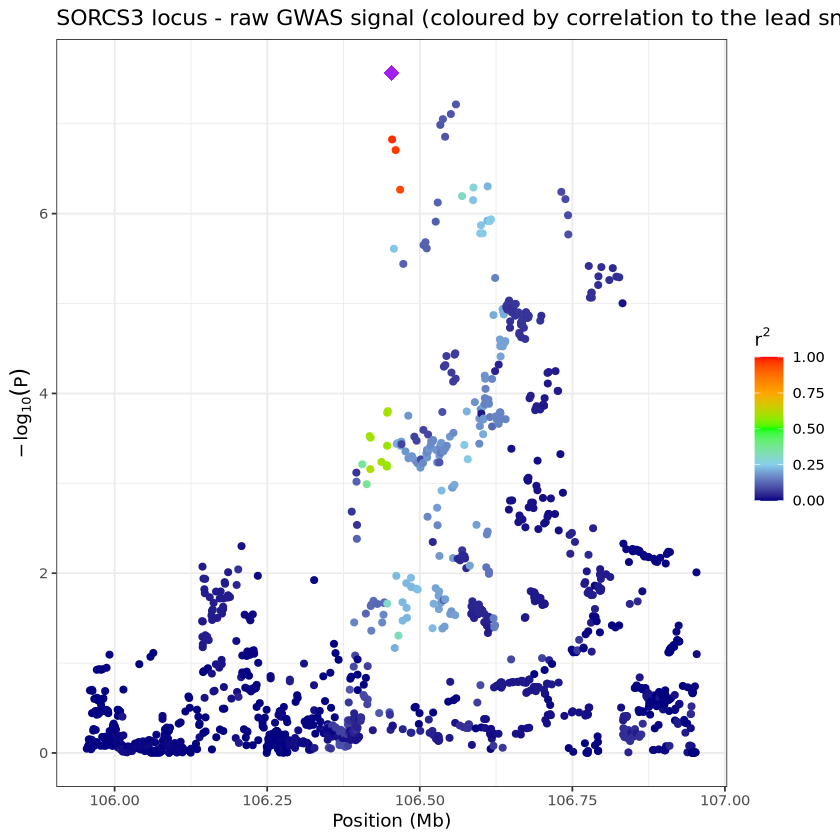

In [6]:
locuszoom_plot(sumstats, ld, title = "SORCS3 locus - raw GWAS signal (coloured by correlation to the lead snp)")

::: callout-note
**Before running SuSiE**: study the plot above.

- The lead SNP (purple diamond) is the most associated, but a whole *peak* of
  SNPs around it is nearly as significant, and red/orange means they are in
  tight LD (high r²) with the lead.
- That is the fine-mapping problem: which of these correlated variants
  is causal? You cannot tell from association strength alone.
- How many SNPs have |Z| > 5? `sum(abs(sumstats$Z) > 5)`
:::

In [9]:
# Run susie_rss() on this locus.
# Docs: https://www.rdocumentation.org/packages/susieR/versions/0.14.2/topics/susie_rss

fit <- susie_rss(
  z = sumstats$Z,   # the per-SNP Z-scores
  R = ld,   # the matched LD matrix (same SNP order as the sumstats)
  n = sumstats$N[1],   # which N for a case/control trait? (see the hint below)
  L = 10    # allow up to this many independent signals
)

HINT: For large R or large XtX, consider installing the Rfast package for better performance.



::: {.callout-tip collapse="true"}
## Hint

- `z` = `sumstats$Z` - the per-SNP Z-scores
- `R` = `ld` - already matched to the same SNP order
- `n` = `sumstats$N[1]` - case/control trait, so this is the **effective N (Neff)**, not the raw case+control total
- `L` = `10` - up to 10 independent signals
:::

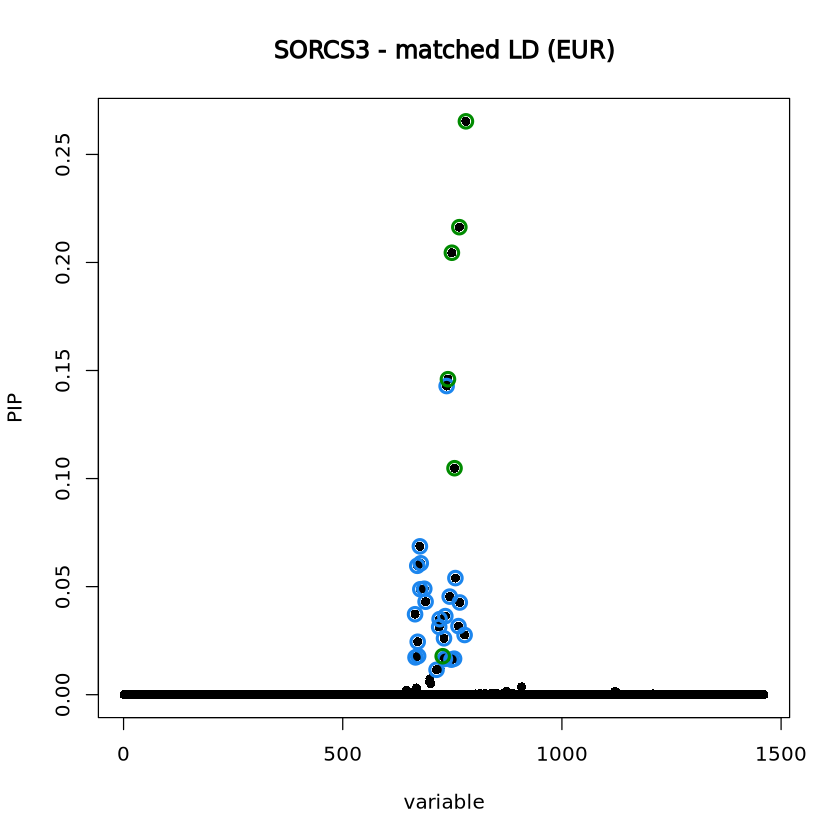

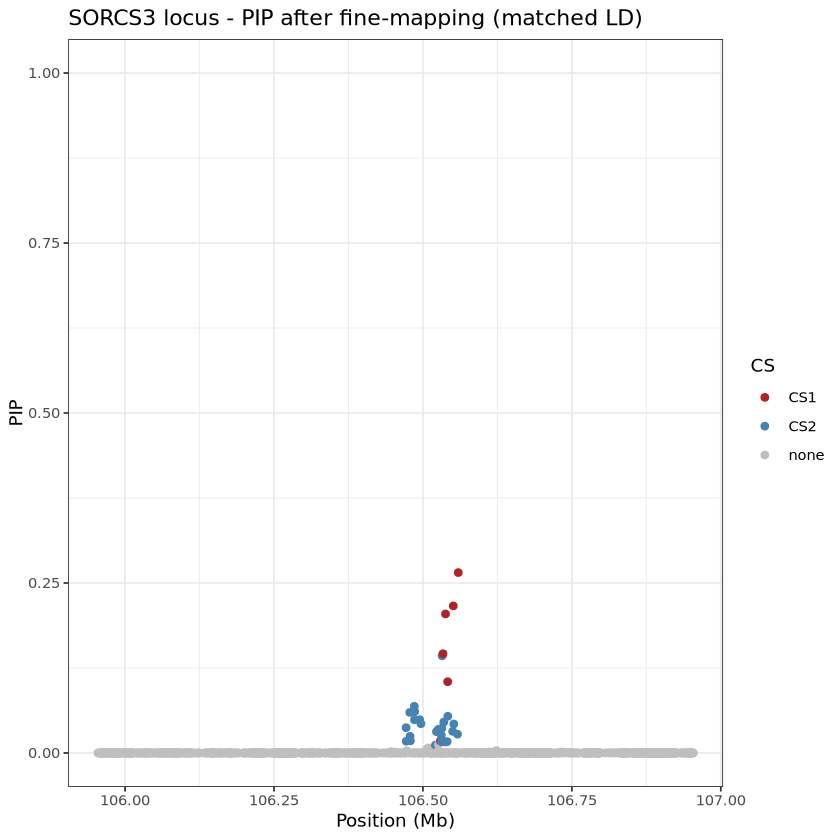

In [10]:
# Plot PIPs along the locus. susie_plot is the built-in view; pip_track() is the
# provided ggplot version (genomic x-axis, coloured by credible set). Compare it
# to the LocusZoom plot above.
susie_plot(fit, y = "PIP", main = "SORCS3 - matched LD (EUR)")
pip_track(fit, sumstats, title = "SORCS3 locus - PIP after fine-mapping (matched LD)")

::: callout-note
**Interpret the output**

1. How many SNPs are in the lead 95% credible set? (`length(fit$sets$cs[[1]])`)
2. What is the top PIP? Run `max(susie_get_pip(fit))`. Is there a single clear
   candidate, or is the posterior spread across a wide set?
3. Check its purity (`fit$sets$purity`): is `min.abs.corr ≥ 0.5`?
4. Which SNP carries the most weight? is it the GWAS lead, rs11596214?

> You may notice SuSiE returns **more than one** credible set here.
:::

In [11]:
#| label: b1-inspect
#| eval: false
# Inspect the credible set and purity.

cat("Converged:", fit$converged, "\n")
cat("Number of credible sets:", length(fit$sets$cs), "\n")
cat("Credible set size:", length(fit$sets$cs[[1]]), "SNPs\n")
cat("Top PIP SNP:", sumstats$SNP[which.max(susie_get_pip(fit))], "\n")
cat("Top PIP value:", round(max(susie_get_pip(fit)), 3), "\n")
cat("\nPurity (min.abs.corr >= 0.5 means acceptable):\n")
print(round(fit$sets$purity, 3))

Converged: TRUE 
Number of credible sets: 2 
Credible set size: 6 SNPs
Top PIP SNP: rs11599313 
Top PIP value: 0.265 

Purity (min.abs.corr >= 0.5 means acceptable):
   min.abs.corr mean.abs.corr median.abs.corr
L1        0.922         0.967           0.976
L2        0.916         0.957           0.950


## Block 2: Mismatched LD panel

Now rerun the **same locus** using `ld_mismatched.RDS` - the **1000G EAS**
panel (East Asian, shorter LD blocks, different haplotype structure than the
European GWAS). The Z-scores are identical, only the reference panel changes.

In [12]:
ld_mm <- readRDS(file.path(data_dir, "locus1_clean", "ld_mismatched.RDS"))

In [14]:
# Rerun susie_rss() with the mismatched LD matrix.
# Everything is identical to Block 1 except the LD panel. Fill in R.

fit_mm <- susie_rss(
  z = sumstats$Z,
  R = ___,                # the mismatched panel loaded just above
  n = sumstats$N[1],
  L = 10
)

HINT: For large R or large XtX, consider installing the Rfast package for better performance.

Warning message in susie_suff_stat(XtX = XtX, Xty = Xty, n = n, yty = (n - 1) * :
“IBSS algorithm did not converge in 100 iterations!
                  Please check consistency between summary statistics and LD matrix.
                  See https://stephenslab.github.io/susieR/articles/susierss_diagnostic.html”


**Run the LD diagnostic**, although susie already prints that something might be wrong

```
# estimate_s_rss() measures global Z-score / LD inconsistency.
# Rule of thumb: s_hat < 0.05 fine, 0.05 to 0.10 marginal, > 0.10 mismatch.
```

In [15]:
# estimate_s_rss() measures global Z-score / LD inconsistency.
# Rule of thumb: s_hat < 0.05 fine, 0.05 to 0.10 marginal, > 0.10 mismatch.


s_matched  <- estimate_s_rss(z = sumstats$Z, R = ld, n = sumstats$N[1])   # matched panel
s_mismatch <- estimate_s_rss(z = sumstats$Z, R = ld_mm, n = sumstats$N[1])   # mismatched panel

cat("s_hat (matched panel):   ", round(s_matched,  4), "\n")
cat("s_hat (mismatched panel):", round(s_mismatch, 4), "\n")

s_hat (matched panel):    0.0092 
s_hat (mismatched panel): 0.6087 


`s_hat` is a single number. The **`kriging_rss`** diagnostic is the per-SNP
version: for each SNP it compares the *observed* z to the value *expected* from
its LD neighbours, and flags outliers (in red), variants whose z is
inconsistent with the reference panel. Under a matched panel the points sit on
the diagonal.



Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the susieR package.
  Please report the issue at <https://github.com/stephenslab/susieR/issues>.”




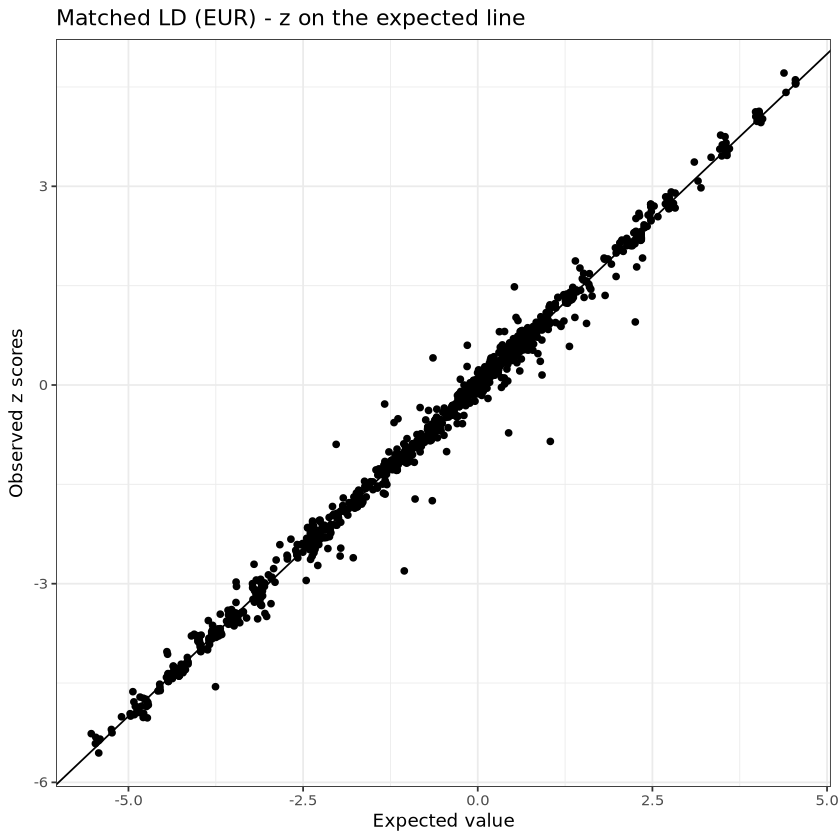

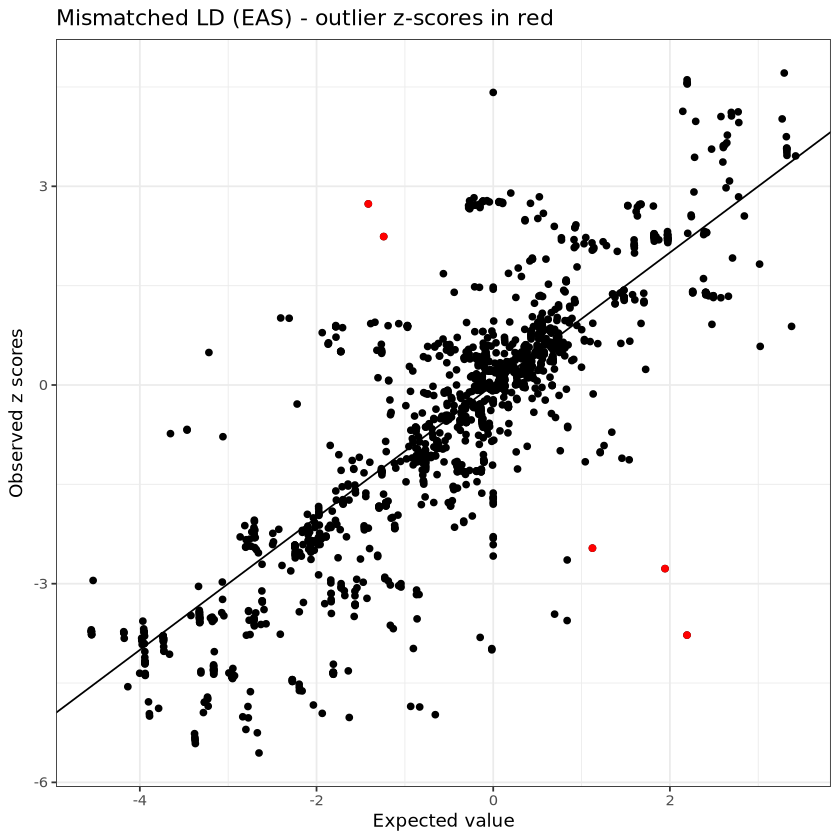

In [16]:
# Run kriging_rss() for each panel and show its diagnostic plot.
# https://www.rdocumentation.org/packages/susieR/versions/0.14.2/topics/kriging_rss
# Same idea, for the matched panel (ld) and the mismatched panel (ld_mm).
k_matched  <- kriging_rss(sumstats$Z, ld, n = sumstats$N[1])   # matched panel
k_mismatch <- kriging_rss(sumstats$Z, ld_mm, n = sumstats$N[1])   # mismatched panel

k_matched$plot  + ggplot2::ggtitle("Matched LD (EUR) - z on the expected line")
k_mismatch$plot + ggplot2::ggtitle("Mismatched LD (EAS) - outlier z-scores in red")

In [ ]:
#| label: b2-compare
#| eval: false
# Compare credible sets side by side.

cat("Matched LD 
")
cat("CS size:  ", length(fit$sets$cs[[1]]), "SNPs\n")
cat("Purity:   ", round(fit$sets$purity[1, "min.abs.corr"], 3), "\n")

cat("\nMismatched LD\n")
cat("CS size:  ", length(fit_mm$sets$cs[[1]]), "SNPs\n")
cat("Purity:   ", round(fit_mm$sets$purity[1, "min.abs.corr"], 3), "\n")

par(mfrow = c(1, 2))
susie_plot(fit,    y = "PIP", main = "Matched LD")
susie_plot(fit_mm, y = "PIP", main = "Mismatched LD")
par(mfrow = c(1, 1))

::: callout-warning
**Signs of LD mismatch what to look for:**

- `s_hat > 0.10`: global inconsistency between Z-scores and the reference LD
- `min.abs.corr < 0.5` in `fit$sets$purity`: credible set contains SNPs that
  are NOT in tight LD with each other, so the set is not a coherent haplotype
- Credible set explodes (50+ SNPs) or shrinks implausibly (1 SNP with PIP ≈ 1
  even when the lead Z is modest)
- PIPs distributed across many SNPs at similar values rather than concentrated
  on a clear candidate

This mismatch is obvious: East Asian LD on a European GWAS. A
mismatch can be less obvious: the *same* ancestry but a different reference panel.
Later you can compare results of two different panels of the same ancestry. Your SuSiE PIPs (1000G EUR LD) and the SBayesRC
PIPs (UKB EUR LD) come from different panels, so they will not be the same.
:::

---

## Block 3: How many signals? The role of L 

*how many independent signals are really here, and how much does the answer depend on your
choices?* `L` is the maximum number of independent signals SuSiE may report.
Re-fit the locus with `L = 1` (assume one causal variant) and with `L = 10`, and compare how many credible sets come back.

In [18]:
fit_l1 <- susie_rss(z = sumstats$Z, R = ld, n = sumstats$N[1], L = ___)   # assume a single causal variant

HINT: For large R or large XtX, consider installing the Rfast package for better performance.



In [19]:
fit_l10 <- susie_rss(z = sumstats$Z, R = ld, n = sumstats$N[1], L = 10)

HINT: For large R or large XtX, consider installing the Rfast package for better performance.



L = 1  → credible sets found: 0 
L = 10 → credible sets found: 2 


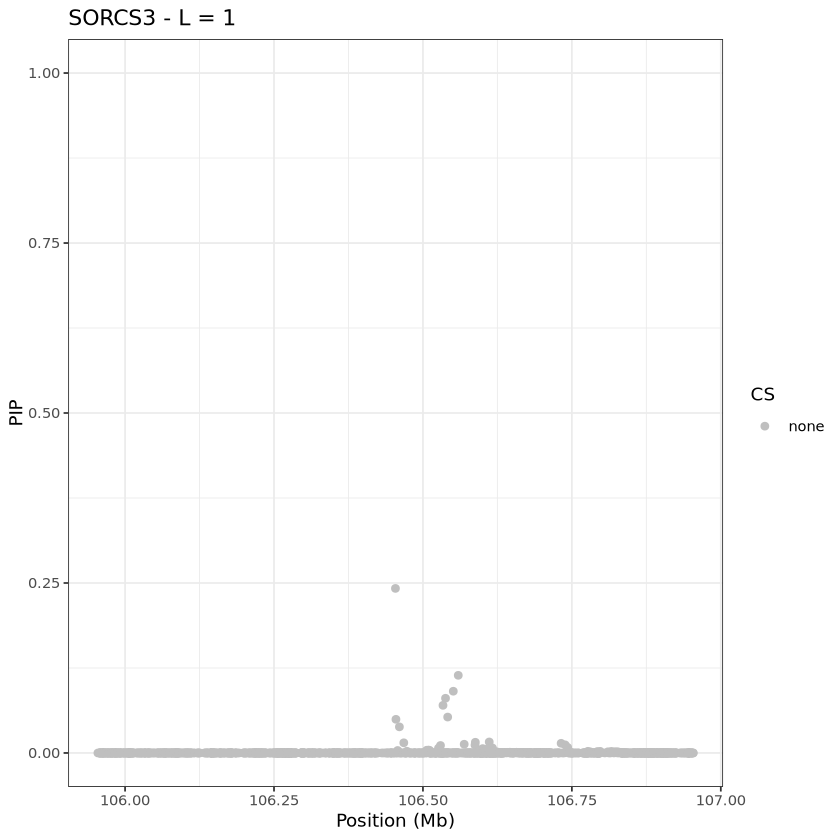

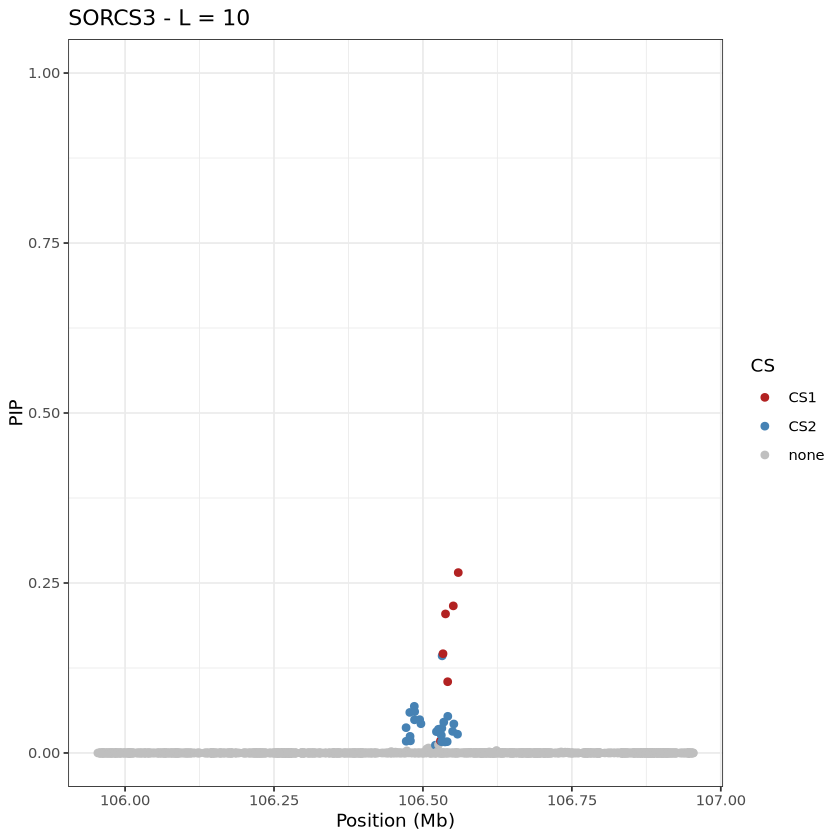

In [20]:
#| label: b3-compare
#| eval: false
# Compare how many credible sets each L returns.

cat("L = 1  → credible sets found:", length(fit_l1$sets$cs),  "\n")
cat("L = 10 → credible sets found:", length(fit_l10$sets$cs), "\n")

pip_track(fit_l1,  sumstats, title = "SORCS3 - L = 1")
pip_track(fit_l10, sumstats, title = "SORCS3 - L = 10")

::: callout-note
**Interpreting `L` and the credible sets.** `L` is the *maximum* number of single-effect
(causal) signals SuSiE may place at the locus. Each 95% credible set is a group of variants ≥95% likely to contain
one causal variant. If we have genotypes available then our fine-mapping would use in-sample LD; with a reference panel
(here 1000G) `susie_rss` is sensitive to LD mismatch and can return a false-positive
credible set, so corroborate any extra set (`estimate_s_rss`)
before calling it a second signal.
:::

::: callout-note
**Questions**

1. How many credible sets at `L = 1` vs `L = 10`? With `L = 1`, SuSiE may return
   **zero** confident sets. Why might forcing a single effect onto this locus
   leave nothing that passes the purity/coverage filter?
2. For any extra credible set at `L = 10`, what is its purity
   (`fit_l10$sets$purity`)? Would you report it?
3. What evidence, beyond this reference-LD fine-map, would you need before
   claiming SORCS3 has two independent causal variants? (in-sample LD,
   conditional analysis, replication)
:::

---

## Block 4: Compare to another method, SBayesRC

SBayesRC (Zheng et al., *Nat Genet* 2024) is a genome-wide fine-mapping method
that runs MCMC over the full set of GWAS SNPs jointly. Very different from
SuSiE's per-locus approach. MCMC can take a while to run, so we provide **pre-computed output** for locus 1. You can find the tutorial here: https://gctbhub.cloud.edu.au/software/gctb/#Genome-wideFine-mappinganalysis

Note that SBayesRC in this run uses a **different LD reference** (UKB EUR) than the SuSiE
fit (1000G EUR). So the results are not directly comparable. We provide them like this to open a discussion about the different methods

In [21]:
sbrc <- fread(file.path(data_dir, "sbayesrc_precomputed", "locus1.snpRes"))
cat("SBayesRC output columns:", paste(names(sbrc), collapse = ", "), "\n")
head(sbrc[order(-PIP), .(Name, Position, b, se, PIP)])

SBayesRC output columns: Name, Chrom, Position, A1, A2, A1Freq, b, se, p, PIP, Var 


Name,Position,b,se,PIP
<chr>,<int>,<dbl>,<dbl>,<dbl>
rs7909129,106457576,-0.008129,0.008721,0.3067860
rs3896224,106467853,0.003326,0.005203,0.2206610
rs731163,106541900,-0.003587,0.006055,0.1291070
rs971527,106551929,-0.002144,0.004272,0.0915063
rs12413206,106469813,-0.001116,0.003006,0.0877369
rs970052,106534351,0.001247,0.003594,0.0848123


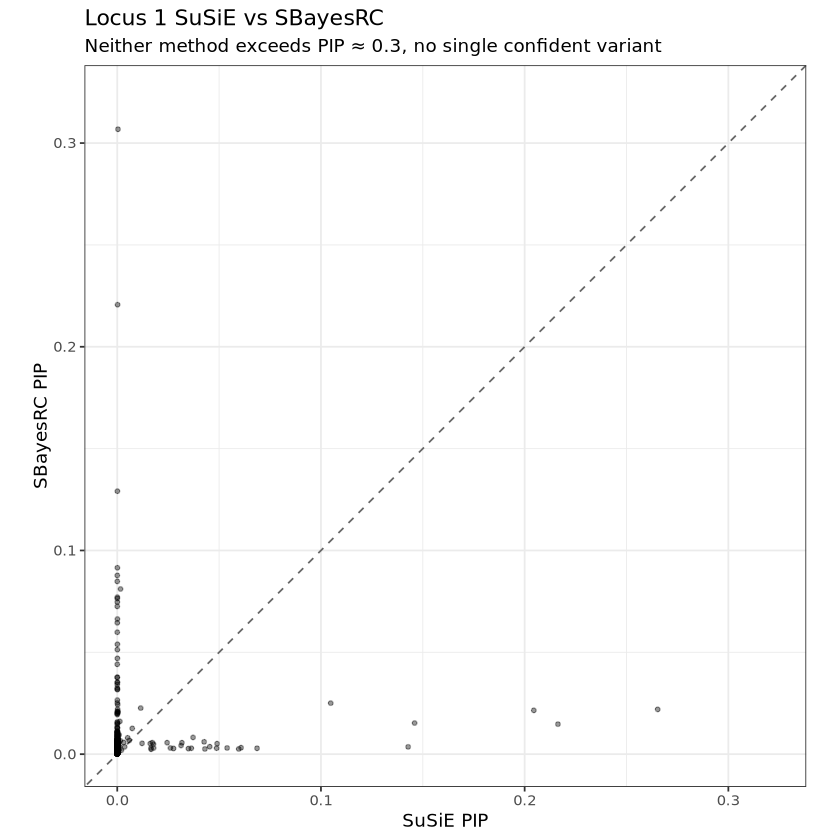

In [22]:
# Build a SuSiE PIP table
pip_susie <- data.table(
  SNP      = sumstats$SNP,
  pip_susie = susie_get_pip(fit)
)

# Merge with SBayesRC on SNP name
merged <- merge(pip_susie, sbrc[, .(Name, pip_sbrc = PIP)],
                by.x = "SNP", by.y = "Name")

lim <- c(0, max(merged$pip_susie, merged$pip_sbrc) * 1.05)

ggplot(merged, aes(x = pip_susie, y = pip_sbrc)) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", colour = "grey40") +
  geom_point(alpha = 0.4, size = 1) +
  coord_equal(xlim = lim, ylim = lim) +
  labs(x = "SuSiE PIP", y = "SBayesRC PIP",
       title = "Locus 1 SuSiE vs SBayesRC",
       subtitle = "Neither method exceeds PIP ≈ 0.3, no single confident variant") +
  theme_bw()

::: callout-note
**Discussion questions:**

1. Do the two methods agree on the **top SNP**? Does SBayesRC give a smaller or
   larger credible set than SuSiE?
2. Which method concentrates PIP more tightly? And is that the **model**, the
   **LD panel** (1000G vs UKB), or both? You cannot fully separate them here.
3. The two methods use fundamentally different models.
   What would drive you to use genome-wide SBayesRC vs locus-based SuSiE
   in a real project?
:::

::: {.callout-tip collapse="true"}
## Answers

1. **No.** SuSiE's top SNP (rs11599313), SBayesRC's (rs7909129) and the GWAS lead
   (rs11596214) are three different variants. SBayesRC returns no discrete set. Its PIP
   is spread across many SNPs (none > 0.31), i.e. effectively broader than SuSiE's.
2. **SuSiE** concentrates more (it forms discrete credible sets); SBayesRC's PIP is
   spread out. But the **model and the LD panel (1000G vs UKB) differ at once**, so you
   can't pin it on either alone.
3. **SBayesRC** for a genome-wide finemapping;
   **SuSiE** when you have a good (ideally in-sample) LD matrix and want per-locus
   credible sets.
:::

### Export credible set for FLAMES (later session)

At the end of this exercise you save the SuSiE credible set in a format
that you can use later for FLAMES.
The expected columns are `SNP` (format `CHR:POS:A1:A2`), `PIP`, `locus_id`.

In [24]:
# Build the FLAMES input file from your fit object.
# Use only SNPs that are members of the lead credible set.

cs_idx  <- ___            # indices of the lead credible set's members (look inside fit$sets$cs)
head(cs_idx)
cs_snps <- sumstats[cs_idx]

flames_ready <- data.table(
  SNP      = paste0(cs_snps$CHR, ":", cs_snps$POS, ":", cs_snps$A1, ":", cs_snps$A2),
  PIP      = susie_get_pip(fit)[cs_idx],
  locus_id = "locus1_SORCS3"
)

out_file <- file.path(out_dir, "credible_sets_for_flames.tsv")
fwrite(flames_ready, out_file, sep = "	")
cat("Saved", nrow(flames_ready), "SNPs to", out_file, "\n")

[1] 728 740 749 755 766 781

Saved 6 SNPs to output/fm_out//credible_sets_for_flames.tsv 
